# Лабораторна робота №2

## NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних

**Мета:** ознайомитися з основами роботи з бібліотеками NumPy, pandas і Matplotlib для аналізу даних, базових операцій та візуалізації результатів.

**Студент:** Вахнюк Михайло 
**Група:** МІТ-31
**Варіант:** 5  
**Предметна область:** сигнал датчика  
**Дата:** 22.09.2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 5
a = -0.45
b = 52.0
sigma = 2.0

rng = np.random.default_rng(seed)

x = np.linspace(0, 20, 100)
y_true = a * x + b
noise = rng.normal(loc=0, scale=sigma, size=x.size)
y_observed = y_true + noise

print("Кількість значень x:", x.size)
print("Перші 5 значень y_true:", y_true[:5])
print("Перші 5 значень y_observed:", y_observed[:5])

Кількість значень x: 100
Перші 5 значень y_true: [52.         51.90909091 51.81818182 51.72727273 51.63636364]
Перші 5 значень y_observed: [50.39613715 49.26037292 51.32145857 52.5681632  53.9084567 ]


In [2]:
data_matrix = np.column_stack((x, y_true, noise, y_observed))

print("Матриця data_matrix:")
print(data_matrix[:5])

print("\nshape:", data_matrix.shape)
print("ndim:", data_matrix.ndim)
print("size:", data_matrix.size)
print("dtype:", data_matrix.dtype)

Матриця data_matrix:
[[ 0.         52.         -1.60386285 50.39613715]
 [ 0.2020202  51.90909091 -2.64871799 49.26037292]
 [ 0.4040404  51.81818182 -0.49672324 51.32145857]
 [ 0.60606061 51.72727273  0.84089048 52.5681632 ]
 [ 0.80808081 51.63636364  2.27209306 53.9084567 ]]

shape: (100, 4)
ndim: 2
size: 400
dtype: float64


In [3]:
print("Перший рядок:")
print(data_matrix[0])

print("\nПерші 3 рядки:")
print(data_matrix[:3])

filtered_matrix = data_matrix[data_matrix[:, 3] > 50]
print("\nКількість спостережень з амплітудою понад 50 мВ:", filtered_matrix.shape[0])

fragment_copy = data_matrix[:3].copy()
fragment_copy[:, 1] = -999
print("\nЗмінена копія фрагмента:")
print(fragment_copy)

print("\nВихідна матриця не змінилась:")
print(data_matrix[:3])

matrix_without_first_row = np.delete(data_matrix, 0, axis=0)
print("\nФорма матриці після видалення першого рядка:", matrix_without_first_row.shape)

Перший рядок:
[ 0.         52.         -1.60386285 50.39613715]

Перші 3 рядки:
[[ 0.         52.         -1.60386285 50.39613715]
 [ 0.2020202  51.90909091 -2.64871799 49.26037292]
 [ 0.4040404  51.81818182 -0.49672324 51.32145857]]

Кількість спостережень з амплітудою понад 50 мВ: 17

Змінена копія фрагмента:
[[ 0.00000000e+00 -9.99000000e+02 -1.60386285e+00  5.03961371e+01]
 [ 2.02020202e-01 -9.99000000e+02 -2.64871799e+00  4.92603729e+01]
 [ 4.04040404e-01 -9.99000000e+02 -4.96723244e-01  5.13214586e+01]]

Вихідна матриця не змінилась:
[[ 0.         52.         -1.60386285 50.39613715]
 [ 0.2020202  51.90909091 -2.64871799 49.26037292]
 [ 0.4040404  51.81818182 -0.49672324 51.32145857]]

Форма матриці після видалення першого рядка: (99, 4)


In [4]:
print("Мінімум y_observed:", np.min(y_observed))
print("Максимум y_observed:", np.max(y_observed))
print("Середнє y_observed:", np.mean(y_observed))
print("Стандартне відхилення y_observed:", np.std(y_observed))

print("\nАгрегація матриці за стовпцями (axis=0):")
print("Середні значення:", np.mean(data_matrix, axis=0))
print("Стандартні відхилення:", np.std(data_matrix, axis=0))

Мінімум y_observed: 39.7810540441581
Максимум y_observed: 54.451384267735335
Середнє y_observed: 47.05198546618067
Стандартне відхилення y_observed: 3.197037744894081

Агрегація матриці за стовпцями (axis=0):
Середні значення: [10.         47.5        -0.44801453 47.05198547]
Стандартні відхилення: [5.8315293  2.62418819 1.76537557 3.19703774]


## Висновок до блоку NumPy

Створено 100 значень X та змодельовано сигнал датчика за лінійною залежністю з випадковим шумом. Матриця `data_matrix` має 100 рядків і 4 стовпці та зберігає X, теоретичні значення, шум і спостережувану амплітуду. Булеву фільтрацію виконано без зміни вихідної матриці, а для зміни фрагмента використано `.copy()`.

Переходимо до pandas. Створи DataFrame та розділи значення X на три рівні інтервали low, medium, high.

In [5]:
group_labels = ["low", "medium", "high"]

df = pd.DataFrame({
    "x": x,
    "y_true": y_true,
    "noise": noise,
    "y_observed": y_observed,
})

df["group"] = pd.cut(
    df["x"],
    bins=3,
    labels=group_labels,
    include_lowest=True
)

df.head()

,x,y_true,noise,y_observed,group
0,0.000000,52.000000,-1.603863,50.396137,low
1,0.202020,51.909091,-2.648718,49.260373,low
2,0.404040,51.818182,-0.496723,51.321459,low
3,0.606061,51.727273,0.840890,52.568163,low
4,0.808081,51.636364,2.272093,53.908457,low


df — це таблиця з даними, а group показує, до якої третини діапазону X належить кожен рядок.

In [6]:
print("Перші 5 рядків:")
display(df.head())

print("Форма таблиці:", df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nІнформація про таблицю:")
df.info()

print("\nОпис числових даних:")
display(df.describe())

Перші 5 рядків:


,x,y_true,noise,y_observed,group
0,0.000000,52.000000,-1.603863,50.396137,low
1,0.202020,51.909091,-2.648718,49.260373,low
2,0.404040,51.818182,-0.496723,51.321459,low
3,0.606061,51.727273,0.840890,52.568163,low
4,0.808081,51.636364,2.272093,53.908457,low


Форма таблиці: (100, 5)

Типи даних:
x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

Інформація про таблицю:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

Опис числових даних:


,x,y_true,noise,y_observed
count,100.000000,100.000000,100.000000,100.000000
mean,10.000000,47.500000,-0.448015,47.051985
std,5.860907,2.637408,1.774269,3.213144
min,0.000000,43.000000,-3.995633,39.781054
25%,5.000000,45.250000,-1.946928,44.994060
50%,10.000000,47.500000,-0.512520,47.050454
75%,15.000000,49.750000,0.613972,49.134595
max,20.000000,52.000000,4.863465,54.451384


Це показує структуру DataFrame: кількість рядків і стовпців, типи даних, наявність/відсутність пропусків та основну статистику.


Тепер штучно створимо проблеми в копії даних: три пропуски та один дубльований рядок.


In [7]:
df_dirty = df.copy()

missing_indices = [5, 25, 75]
df_dirty.loc[missing_indices, "y_observed"] = np.nan

df_dirty = pd.concat(
    [df_dirty, df_dirty.iloc[[0]]],
    ignore_index=True
)

print("Форма таблиці після додавання дубля:", df_dirty.shape)
print("\nКількість пропусків у кожному стовпці:")
print(df_dirty.isna().sum())

print("\nКількість дублікатів:", df_dirty.duplicated().sum())

Форма таблиці після додавання дубля: (101, 5)

Кількість пропусків у кожному стовпці:
x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64

Кількість дублікатів: 1


Очікувано: у y_observed буде 3 пропуски, а кількість дублікатів буде 1.

Тепер очистимо дані.

In [8]:
df_clean = df_dirty.drop_duplicates().copy()
print("Форма після видалення дубля:", df_clean.shape)

median_y = df_clean["y_observed"].median()
df_clean.loc[:, "y_observed"] = df_clean["y_observed"].fillna(median_y)

print("Форма після заповнення пропусків:", df_clean.shape)
print("\nПропуски після очищення:")
print(df_clean.isna().sum())

print("\nКількість дублікатів після очищення:", df_clean.duplicated().sum())

Форма після видалення дубля: (100, 5)
Форма після заповнення пропусків: (100, 5)

Пропуски після очищення:
x             0
y_true        0
noise         0
y_observed    0
group         0
dtype: int64

Кількість дублікатів після очищення: 0


## Очищення даних

До копії таблиці було штучно додано три пропуски та один дубльований рядок. Дубль видалено, а пропуски у `y_observed` заповнено медіаною. Медіана є стійкою до можливих викидів, тому не зміщує результат так сильно, як середнє значення.

Тепер продемонструємо loc, iloc, фільтрацію та сортування.

In [9]:
print("loc — рядки з group = high, стовпці x та y_observed:")
display(df_clean.loc[df_clean["group"] == "high", ["x", "y_observed"]].head())

print("iloc — перші 5 рядків і перші 3 стовпці:")
display(df_clean.iloc[0:5, 0:3])

print("Булева фільтрація — амплітуда понад 50 мВ:")
display(df_clean[df_clean["y_observed"] > 50].head())

print("Сортування за y_observed за спаданням:")
display(df_clean.sort_values("y_observed", ascending=False).head())

loc — рядки з group = high, стовпці x та y_observed:


,x,y_observed
67,13.535354,45.866644
68,13.737374,47.036615
69,13.939394,44.997455
70,14.141414,45.331640
71,14.343434,46.030217


iloc — перші 5 рядків і перші 3 стовпці:


,x,y_true,noise
0,0.000000,52.000000,-1.603863
1,0.202020,51.909091,-2.648718
2,0.404040,51.818182,-0.496723
3,0.606061,51.727273,0.840890
4,0.808081,51.636364,2.272093


Булева фільтрація — амплітуда понад 50 мВ:


,x,y_true,noise,y_observed,group
0,0.000000,52.000000,-1.603863,50.396137,low
2,0.404040,51.818182,-0.496723,51.321459,low
3,0.606061,51.727273,0.840890,52.568163,low
4,0.808081,51.636364,2.272093,53.908457,low
6,1.212121,51.454545,-1.105295,50.349251,low


Сортування за y_observed за спаданням:


,x,y_true,noise,y_observed,group
9,1.818182,51.181818,3.269566,54.451384,low
13,2.626263,50.818182,3.200038,54.018220,low
4,0.808081,51.636364,2.272093,53.908457,low
8,1.616162,51.272727,1.497492,52.770219,low
3,0.606061,51.727273,0.840890,52.568163,low


- **loc вибирає дані за умовою або назвою стовпця.**
- **iloc вибирає дані за числовою позицією.**

Тепер групування за group

In [10]:
grouped = df_clean.groupby("group", observed=True)

summary = grouped["y_observed"].agg(["mean", "std"])
summary["size"] = grouped.size()

summary = summary.rename(columns={
    "mean": "mean_y_observed",
    "std": "std_y_observed",
    "size": "rows_count"
})

display(summary)

,mean_y_observed,std_y_observed,rows_count
group,,,
low,49.755794,2.098642,34
medium,47.295360,1.887750,33
high,43.882661,1.934743,33


## Групування даних

Дані згруповано за трьома інтервалами X: `low`, `medium` і `high`. Для кожної групи обчислено середню амплітуду, стандартне відхилення та кількість рядків. Метод `size()` рахує всі рядки групи, а `count()` не враховує пропуски у вибраному стовпці.

Далі обчислимо похибки MAE і MSE та додамо їх у таблицю.

In [11]:
df_clean["absolute_error"] = np.abs(
    df_clean["y_observed"] - df_clean["y_true"]
)

df_clean["squared_error"] = (
    df_clean["y_observed"] - df_clean["y_true"]
) ** 2

mae = np.mean(df_clean["absolute_error"])
mse = np.mean(df_clean["squared_error"])

print(f"MAE = {mae:.4f} мВ")
print(f"MSE = {mse:.4f} мВ²")

assert mae >= 0
assert mse >= 0

MAE = 1.5286 мВ
MSE = 3.5319 мВ²


- MAE — середня абсолютна похибка в мВ.
- MSE — середня квадратична похибка в мВ²; вона сильніше реагує на великі відхилення.

Тепер побудуємо два графіки й збережемо їх як PNG

Рисунок збережено: C:\Users\Михайло\Data_Science_Labs\Lab2\Lab2_figure.png


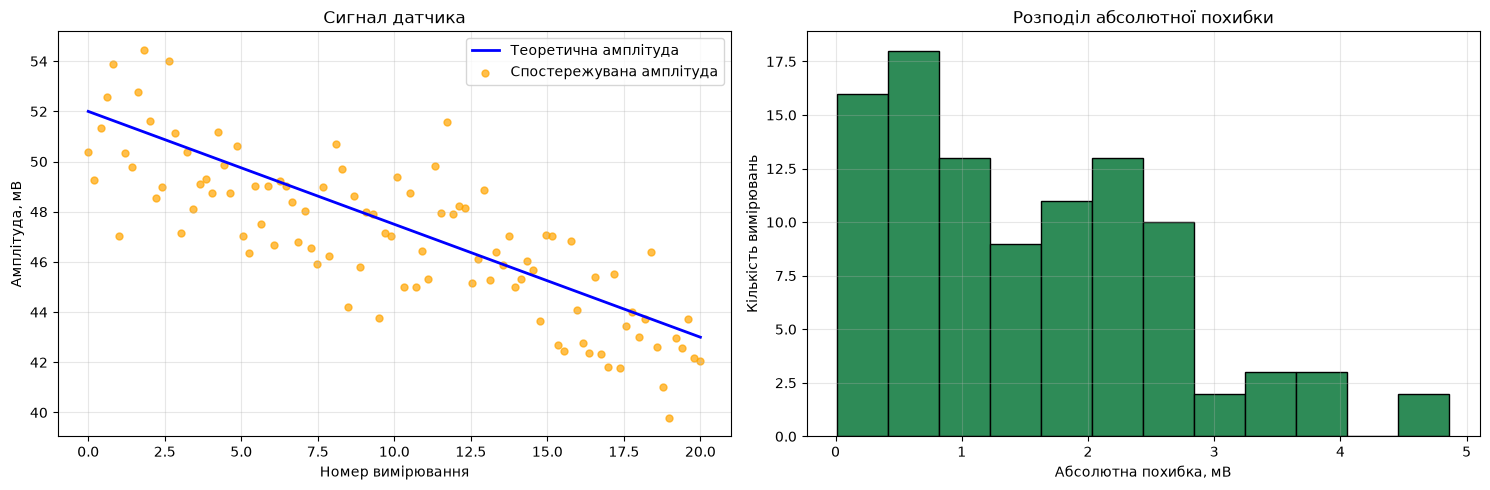

In [12]:
from pathlib import Path

output_dir = Path(".")
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Графік 1: теоретичний і спостережуваний сигнал
axes[0].plot(
    df_clean["x"],
    df_clean["y_true"],
    color="blue",
    linewidth=2,
    label="Теоретична амплітуда"
)

axes[0].scatter(
    df_clean["x"],
    df_clean["y_observed"],
    color="orange",
    alpha=0.7,
    s=25,
    label="Спостережувана амплітуда"
)

axes[0].set_title("Сигнал датчика")
axes[0].set_xlabel("Номер вимірювання")
axes[0].set_ylabel("Амплітуда, мВ")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Графік 2: розподіл абсолютної похибки
axes[1].hist(
    df_clean["absolute_error"],
    bins=12,
    color="seagreen",
    edgecolor="black"
)

axes[1].set_title("Розподіл абсолютної похибки")
axes[1].set_xlabel("Абсолютна похибка, мВ")
axes[1].set_ylabel("Кількість вимірювань")
axes[1].grid(alpha=0.3)

fig.tight_layout()

figure_path = output_dir / "Lab2_figure.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

print("Рисунок збережено:", figure_path.resolve())
plt.show()

Тепер збережемо результати у CSV, Parquet та агреговану таблицю.

In [13]:
results_csv_path = output_dir / "Lab2_results.csv"
results_parquet_path = output_dir / "Lab2_results.parquet"
summary_csv_path = output_dir / "Lab2_summary.csv"

df_clean.to_csv(results_csv_path, index=False)
df_clean.to_parquet(results_parquet_path, index=False)

summary_to_save = summary.reset_index()
summary_to_save.to_csv(summary_csv_path, index=False)

df_from_csv = pd.read_csv(results_csv_path)

print("CSV збережено:", results_csv_path.resolve())
print("Parquet збережено:", results_parquet_path.resolve())
print("Агреговану таблицю збережено:", summary_csv_path.resolve())

print("\nФорма очищеного DataFrame:", df_clean.shape)
print("Форма DataFrame після повторного читання CSV:", df_from_csv.shape)

assert df_clean.shape == df_from_csv.shape

CSV збережено: C:\Users\Михайло\Data_Science_Labs\Lab2\Lab2_results.csv
Parquet збережено: C:\Users\Михайло\Data_Science_Labs\Lab2\Lab2_results.parquet
Агреговану таблицю збережено: C:\Users\Михайло\Data_Science_Labs\Lab2\Lab2_summary.csv

Форма очищеного DataFrame: (100, 7)
Форма DataFrame після повторного читання CSV: (100, 7)


## Висновок

Було змодельовано сигнал датчика для варіанта 5 за лінійною залежністю та випадковим шумом. Дані опрацьовано засобами NumPy і pandas: виконано перевірку структури, очищення пропусків, видалення дубля та групування за інтервалами X. Побудовано графік теоретичної та спостережуваної амплітуди, а також гістограму абсолютної похибки. Отримано MAE = 1.5286 мВ і MSE = 3.5319 мВ². Менші значення MAE і MSE означають меншу похибку моделі.